# Testbench for `conv1d_w1()`

In [1]:
#
# Copyright (C) 2024, Advanced Micro Devices, Inc. All rights reserved.
# SPDX-License-Identifier: MIT
#
# Author: Faisal El-Shabani

In [2]:
from tensorflow import keras
from tensorflow.keras.layers import Conv1D
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import h5py as h5
import numpy as np
import os.path
import vfs
import varray as va

NITERATIONS = 4    # Number of AI Engine graph iterations

2025-09-03 12:27:57.423569: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-03 12:27:57.428078: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-03 12:27:57.437626: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756924077.452971 2366580 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756924077.457569 2366580 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756924077.471135 2366580 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Layer Definition

In [3]:
inputs = keras.Input(shape=(1024,2),name="input")
outputs = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w1",activation='relu')(inputs)
model = keras.Model(inputs=inputs,outputs=outputs)
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
w_weights = np.loadtxt('w1_weights_trained.txt')
w_weights = (w_weights.astype("bfloat16")).astype("float32")
w_weights = np.reshape(w_weights,(7,2,64))
w_bias = np.loadtxt('w1_bias_trained.txt')
w_bias = (w_bias.astype("bfloat16")).astype("float32")
model.set_weights((w_weights,w_bias))

2025-09-03 12:28:01.528909: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1024, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w1 (Conv1D)              │ (None, 1024, 64)       │           960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 960 (3.75 KB)

 Trainable params: 960 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

### Read training and test data

In [5]:
if not("RADIOML_DATA" in os.environ):
   print("Please set environment variable RADIOML_DATA to point to dataset found in https://www.kaggle.com/datasets/pinxau1000/radioml2018")
data_file = os.environ["RADIOML_DATA"] + 'GOLD_XYZ_OSC.0001_1024.hdf5'
file_handle = h5.File(data_file,'r')
myData = file_handle['X'][:]  #1024x2 samples 
myMods = file_handle['Y'][:]  #mods 
mySNRs = file_handle['Z'][:]  #snrs  
file_handle.close()
X_train ,X_predict ,Y_train ,Y_test, Z_train, Z_test =train_test_split(myData, myMods, mySNRs, test_size=0.2, random_state=0)
X_predict = X_predict[:NITERATIONS]
X_predict = (X_predict.astype("bfloat16")).astype("float32")


## Compute Golden Outputs

In [6]:
predict = model.predict(X_predict, batch_size=1024)
predict = predict.astype("bfloat16").astype("float32")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


## Store Layer Inputs

In [7]:
# Create directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')
data_iq = np.reshape(X_predict,(-1,1))
np.savetxt('data/data_iq.txt',np.reshape(data_iq,(-1,4)),fmt='%.12f %.12f %.12f %.12f')
print(X_predict.shape)
print(data_iq.shape)

(4, 1024, 2)
(8192, 1)


## Store Layer Outputs

In [8]:
data_o = np.array([],dtype='float32')
for i in range(NITERATIONS):
    data_o = np.concat((data_o,np.reshape(np.transpose(predict[i,:,:]),(-1))))
np.savetxt('data/data_o.txt',np.reshape(data_o,(-1,4)),fmt='%.12f %.12f %.12f %.12f')
print(data_o.shape)

(262144,)


## Store Model weights and biases

In [9]:
print(w_weights.shape)
print(w_bias.shape)
weights = np.reshape(w_weights,(-1,1))
biases = np.reshape(w_bias,(-1,1))
np.savetxt('data/weights-rtp.txt',weights,fmt='%.12f')
np.savetxt('data/biases-rtp.txt',biases,fmt='%.12f')
print(weights.shape)
print(biases.shape)


(7, 2, 64)
(64,)
(896, 1)
(64, 1)


## Run Vitis Functional Simulation

In [10]:
conv1d_w1_graph = vfs.aieGraph(
    input_file='conv1d_w1_app.cpp',
    part="xc2ve3858-ssva2112-2MP-e-S",
    include_paths=['./','../utility'])
act_o = conv1d_w1_graph.run(va.array(data_iq, dtype=va.bfloat16),va.array(weights, dtype=va.bfloat16),va.array(biases, dtype=va.bfloat16))
act_o = np.array(act_o)



Compiling AIE Graph
Compilation directory: /group/fndprod/faisale/repo/internal/designs/radio-ml/aie/conv1d_w1/vfs_work/conv1d_w1_app_f436b85d
Compilation command: v++ -c --mode aie --config vfs_work/conv1d_w1_app_f436b85d/conv1d_w1_app.cfg --work_dir vfs_work/conv1d_w1_app_f436b85d/Work --output vfs_work/conv1d_w1_app_f436b85d/libadf.a --target x86sim
Writing log to: /group/fndprod/faisale/repo/internal/designs/radio-ml/aie/conv1d_w1/vfs_work/conv1d_w1_app_f436b85d/Work/logs/aie_x86sim.log
Please wait ...

Compilation finished successfully.
Loaded AIEGraph


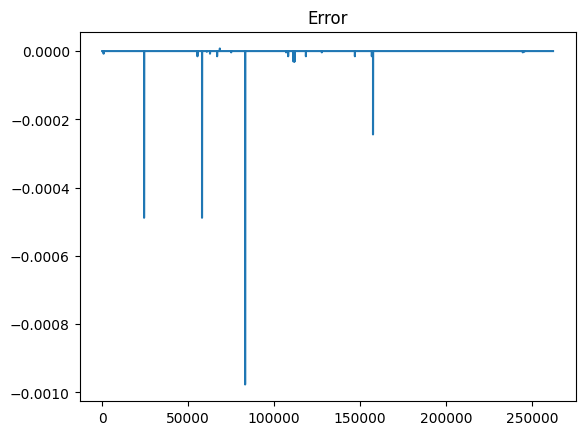

In [11]:
err = data_o-act_o
plt.plot(err)
plt.title("Error")
plt.show()
